<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 12/13 — Economic Delta-CIT & Dashboard Forecast Export

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[11]` ใน `pipeline/run_all.py` (รวมไฟล์เดิม 10_economic_evaluation.ipynb +
12_cit_forecast_export.ipynb เป็นไฟล์เดียว 2026-07-19 เพราะรันติดกันจริงใน CHAIN เป็น notebook สุดท้าย
ทั้งคู่ในสายหลัก โดยไม่มีสคริปต์อื่นแทรกระหว่างกลาง)

**ตอบคำถามอะไร (2 ส่วนในไฟล์นี้):**
1. **Part 1 — Economic Delta-CIT:** เทรนเฉพาะช่วงหลัง TAM ที่ยืนยันว่าสะอาดจริง (2024-06-14) แล้ววัด
   Δ CIT จากจุดนั้น — cross-check ΔCIT ด้วยวิธีที่ 3 ที่เป็นอิสระจากโมเดล
2. **Part 2 — Dashboard Forecast Export:** รวบผลจาก step ก่อนหน้า (time-to-clean / SHAP / model
   metrics) พยากรณ์ล่วงหน้า 182 วัน แล้ว export JSON หลักเกือบทั้งหมดให้แดชบอร์ด — notebook สุดท้าย
   ใน CHAIN หลัก ตามด้วย post-processor scripts + `17_tam_constraint_analysis.ipynb` +
   `13_cleaning_plan_optimization.ipynb`

**Input:** `Process_information_with_crude.csv`, วันที่ TAM ยืนยันแล้ว (Part 1); `Time_To_Clean_Prediction.csv`,
`hx_Q_cleaning_priority_v2.csv`, model metrics (Part 2)

**Output:** `clean_baseline_sandbox.json` (Part 1, **ใช้จริง** — เป็นฐานของ measured-ΔCIT ที่
`export_economics.py` ใช้ก่อนเสมอ), `Delta_CIT_*.csv` (Part 1); dashboard JSON หลัก (Part 2)

**แดชบอร์ด:** Part 1 ป้อนตัวเลข ΔCIT ที่วัดจริงให้แท็บ "เตา & Optimization" ผ่าน
`pipeline/export_economics.py`; Part 2 ป้อนแท็บ "พยากรณ์ & ความเสี่ยง" และ "โมเดล & Optimization" โดยตรง

**Requirements ที่เกี่ยวข้อง:** เศรษฐศาสตร์/measured-ΔCIT-first (`docs/03` — ΔCIT จากโมเดล over-estimate
~3× vs วัดจริง จึงต้องมีวิธีวัดจริงแบบนี้ไว้ก่อนเสมอ)

---


# 6d. Clean-State Baseline & Delta-CIT Fouling Indicator

Restructures the CIT model around two 2020-2025 reference methods instead of
the autoregressive nowcast `6a`/`6b` use:

1. **Clean-State Baseline** (Ujevic Andrijic & Rimac, *Sensors* 2025; already
   adapted once in this project for per-HX duty in
   `06_fouling_rate_forecast.ipynb`) -- train **only** on the plant-wide
   post-TAM window (2024-06-14 + 30 days, the one confirmed time the *entire*
   16-HX train was simultaneously clean), so the model only ever learns the
   clean heat-transfer relationship, never a fouled one.
2. **Delta-CIT residual fouling indicator** (2020 MSc thesis methodology) --
   instead of predicting *actual* CIT (which `6a` does, using yesterday's CIT
   as the dominant feature), this model predicts **Expected Clean CIT** from
   physical operating conditions only, and
   `Delta_CIT = actual_CIT - predicted_clean_CIT` becomes the fouling
   indicator: ~0 right after a clean, increasingly negative as the train
   fouls.

**Why this differs from `6a`/`6b` (kept, not replaced):** `6a` answers "what
model architecture nowcasts CIT most accurately" (needs CIT_lag1 to do that
well). This notebook answers a different question -- "how much is fouling
alone costing us in CIT, right now, and what would cleaning HX X recover" --
which requires the model to *not* know today's actual CIT, otherwise
`Delta_CIT` would just be the model's own residual noise, not a fouling
signal.

Sections:
1. Physical-only feature matrix (no `CIT_lag`/`CIT_roll`, no fouling-state features)
2. Clean-baseline window (plant-wide TAM, 2024-06-14 + 30 days) -- sanity check
3. Candidate feature sets + chronological in-window validation
4. Fit champion on full clean window; compute Delta-CIT over full history
5. Delta-CIT sanity checks and export
6. Optimization Sandbox -- per-HX "reset to clean" counterfactual CIT gain
7. Limitations

## 0. Imports & Configuration

In [1]:
import warnings, sys
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
from pathlib import Path

sys.path.append(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
from src.features.heat_duty import (build_cit_feature_matrix, get_clean_baseline_mask,
                           get_start_of_run_points, get_tam_dates, TAM_DATE,
                           CLEAN_BASELINE_DAYS, HX_CONFIG)

from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

REPO_ROOT  = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
FIG_DIR    = REPO_ROOT / 'figures' / 'clean_baseline'
OUT_DIR    = REPO_ROOT / 'outputs'
MODELS_DIR = REPO_ROOT / 'models'
DASH_DIR   = REPO_ROOT / 'dashboard' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Clean-baseline TAM windows: {[d.date() for d in get_tam_dates()]} + {CLEAN_BASELINE_DAYS} days')

Clean-baseline TAM windows: [datetime.date(2021, 3, 25)] + 30 days


---
## 1. Physical-Only Feature Matrix

`include_cit_lags=False, include_fouling_state=False` strips out everything
that would let the model shortcut to the fouled answer: `CIT_lag1`/`CIT_lag7`/
`CIT_roll7` (yesterday's *actual*, already-fouled CIT) and the
`Rf_run_lag1`/`U_relative_lag1`/`days_on_duty`/`initiation_phase` block added
in `6a` v3 (those directly encode current fouling extent -- exactly the thing
this model must predict *around*, not condition on).

`month_sin`/`month_cos`/`flue_O2` are dropped here too: the one calibration
window is a single June, so a seasonality term can't be learned from it (it's
near-constant across the whole training window) and would just add noise to
an already very small fit.

In [2]:
bundle = build_cit_feature_matrix(include_cit_lags=False, include_fouling_state=False)
X_all, y_all = bundle['X'], bundle['y']
X_all = X_all.drop(columns=['month_sin', 'month_cos', 'flue_O2'])

print(f'Physical-only feature matrix: {X_all.shape[0]} rows x {X_all.shape[1]} features')
print(f'Date range: {X_all.index.min().date()} -> {X_all.index.max().date()}')
print(f'\nFeatures: {list(X_all.columns)}')

Physical-only feature matrix: 1898 rows x 55 features


Date range: 2021-01-01 -> 2026-07-01

Features: ['E101AB_Q_norm', 'E101AB_dT_cold', 'E101AB_dT_hot', 'E101CD_Q_norm', 'E101CD_dT_cold', 'E101CD_dT_hot', 'E101EF_Q_norm', 'E101EF_dT_cold', 'E101EF_dT_hot', 'E102_Q_norm', 'E102_dT_cold', 'E102_dT_hot', 'E103AB_Q_norm', 'E103AB_dT_cold', 'E103AB_dT_hot', 'E104_Q_norm', 'E104_dT_cold', 'E104_dT_hot', 'E105AB_Q_norm', 'E105AB_dT_cold', 'E105AB_dT_hot', 'E106AB_Q_norm', 'E106AB_dT_cold', 'E106AB_dT_hot', 'E107AB_Q_norm', 'E107AB_dT_cold', 'E107AB_dT_hot', 'E108AB_Q_norm', 'E108AB_dT_cold', 'E108AB_dT_hot', 'E109AB_Q_norm', 'E109AB_dT_cold', 'E109AB_dT_hot', 'E110ABC_Q_norm', 'E110ABC_dT_cold', 'E110ABC_dT_hot', 'E111_Q_norm', 'E111_dT_cold', 'E111_dT_hot', 'E112AB_Q_norm', 'E112AB_dT_cold', 'E112AB_dT_hot', 'E112C_Q_norm', 'E112C_dT_cold', 'E112C_dT_hot', 'E113A_dT_hot', 'E113A_cold_in', 'total_charge', 'crude_leadin_filled', 'crude_API', 'crude_SG_15_6C', 'crude_Visc_50C_cSt', 'crude_Visc_100C_cSt', 'crude_MCRT_pct', 'crude_Asphaltenes_pct

---
## 2. Clean-Baseline Window -- Sanity Check

If the TAM on 2024-06-14 really put the train in its best state, CIT in the
30 days after should sit near the *top* of CIT's entire historical range --
not just "different," but specifically higher (more heat recovered, less
furnace duty needed). This is the load-bearing assumption for everything
that follows, so it's checked explicitly rather than assumed.

Clean-baseline window: 30 rows, 2021-03-25 -> 2021-04-23

CIT in clean window:  mean=257.2  min=252.2  max=262.1
CIT full history:     mean=248.1  min=229.6  max=264.4
Clean-window CIT sits at the 93th percentile of full-history CIT -- confirms the TAM window is genuinely the cleanest period, not an arbitrary one.


Start of Run (2021-03-25 TAM): peak CIT = 262.1 C on 2021-04-15


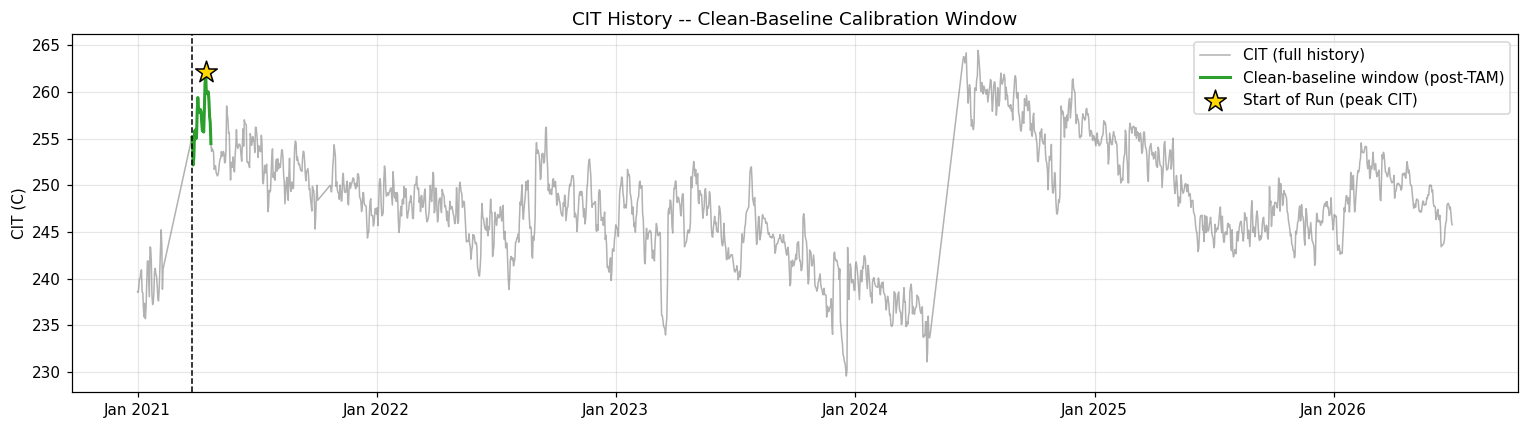

In [3]:
clean_mask = get_clean_baseline_mask(X_all.index)
print(f'Clean-baseline window: {clean_mask.sum()} rows, '
      f'{X_all.index[clean_mask].min().date()} -> {X_all.index[clean_mask].max().date()}')

cit_in_window = y_all[clean_mask]
cit_full = y_all
print()
print(f'CIT in clean window:  mean={cit_in_window.mean():.1f}  min={cit_in_window.min():.1f}  max={cit_in_window.max():.1f}')
print(f'CIT full history:     mean={cit_full.mean():.1f}  min={cit_full.min():.1f}  max={cit_full.max():.1f}')
print(f'Clean-window CIT sits at the {(cit_full < cit_in_window.mean()).mean()*100:.0f}th percentile of full-history CIT'
      f' -- confirms the TAM window is genuinely the cleanest period, not an arbitrary one.')

# Start-of-Run: the single highest-CIT day within each TAM's window, not the whole
# window -- this is the true zero-fouling anchor point per run, right before fouling
# starts pulling CIT back down.
sor_points = get_start_of_run_points(X_all.index, y_all)
for td, (peak_ts, peak_val) in sor_points.items():
    print(f'Start of Run ({td.date()} TAM): peak CIT = {peak_val:.1f} C on {peak_ts.date()}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_all.index, y_all, lw=1, color='tab:gray', alpha=0.6, label='CIT (full history)')

# Plot each TAM's window as its own disconnected segment -- concatenating clean_mask
# across TAM windows into one ax.plot() call draws a straight line across the
# multi-year gap between windows, which is a plotting artifact, not real data.
first = True
for td in sor_points:
    seg_mask = (X_all.index >= td) & (X_all.index < td + pd.Timedelta(days=CLEAN_BASELINE_DAYS))
    ax.plot(y_all.index[seg_mask], y_all[seg_mask], lw=2, color='tab:green',
            label='Clean-baseline window (post-TAM)' if first else None)
    first = False

# Mark the Start-of-Run peak point for each TAM
sor_dates = [p[0] for p in sor_points.values()]
sor_vals  = [p[1] for p in sor_points.values()]
ax.scatter(sor_dates, sor_vals, marker='*', s=220, color='gold', edgecolor='black',
           zorder=5, label='Start of Run (peak CIT)')

for td in sor_points:
    ax.axvline(td, color='black', ls='--', lw=1)
ax.set_ylabel('CIT (C)')
ax.set_title('CIT History -- Clean-Baseline Calibration Window')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'clean_baseline_window.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 3. Candidate Feature Sets + In-Window Validation

Only ~30 rows are available to fit on -- far too few for all 55 physical
columns. Two lean candidates, both far smaller than the sample size:

- **minimal**: `total_charge` + crude assay only (7 features) -- the most
  conservative baseline, no per-HX duty at all.
- **top5_hx**: minimal + the 5 HX `6a`/`6b` already identified as most
  important to CIT (`E109AB`, `E101AB`, `E105AB`, `E101EF`, `E113A`) -- fewer
  features than pooling all 16 HX, and critically, these are the HX the
  Optimization Sandbox (§6) needs to be able to reset individually.

`RidgeCV` (not XGBoost/RandomForest): with ~20 training rows, tree ensembles
would just memorize them; a regularized linear model is the only defensible
choice at this sample size, same conclusion `3a` reached for its per-HX
baseline (`ridge` was its most stable model on limited per-cycle data).

Validated with `3a`'s exact convention: chronological split at day 21 of the
30-day window (train on days 0-21, test on days 22-30) -- checks forward
extrapolation *within* the clean window, which is what the model then has to
do for the next ~2 years once applied to the full deployment period.

In [4]:
TOP5_HX = ['E109AB', 'E101AB', 'E105AB', 'E101EF', 'E113A']

def hx_cols(hx):
    return [c for c in X_all.columns if c.startswith(hx + '_')]

crude_cols = [c for c in X_all.columns if c.startswith('crude_')]
candidate_features = {
    'minimal': ['total_charge'] + crude_cols,
    'top5_hx': ['total_charge'] + crude_cols + sum((hx_cols(hx) for hx in TOP5_HX), []),
}
for name, cols in candidate_features.items():
    print(f'{name}: {len(cols)} features')

# Measure age relative to each row's own detected TAM window.  Using the
# single fallback TAM_DATE here left one side empty whenever detection
# returned a different or multiple TAM dates.
clean_index = X_all.index[clean_mask]
tam_dates = get_tam_dates()
days_since_tam = np.array([
    min((ts - td).days for td in tam_dates
        if 0 <= (ts - td).days < CLEAN_BASELINE_DAYS)
    for ts in clean_index
])
train_in_window = days_since_tam <= 21

X_window = X_all[clean_mask]
y_window = y_all[clean_mask]
X_win_train, X_win_test = X_window[train_in_window], X_window[~train_in_window]
y_win_train, y_win_test = y_window[train_in_window], y_window[~train_in_window]
print(f'\nIn-window split: train={len(X_win_train)} rows (day 0-21), test={len(X_win_test)} rows (day 22-29)')
if X_win_train.empty or X_win_test.empty:
    raise ValueError('Clean-baseline chronological split is empty; check detected TAM dates and feature coverage')

minimal: 8 features
top5_hx: 22 features

In-window split: train=22 rows (day 0-21), test=8 rows (day 22-29)


In [5]:
candidate_results = []
fitted_candidates = {}
for name, cols in candidate_features.items():
    model = RidgeCV(alphas=np.logspace(-2, 3, 30))
    model.fit(X_win_train[cols], y_win_train)
    pred_test = model.predict(X_win_test[cols])
    pred_train = model.predict(X_win_train[cols])
    candidate_results.append({
        'candidate'    : name,
        'n_features'   : len(cols),
        'alpha'        : model.alpha_,
        'train_r2'     : r2_score(y_win_train, pred_train),
        'test_r2'      : r2_score(y_win_test, pred_test),
        'test_mae_C'   : mean_absolute_error(y_win_test, pred_test),
    })
    fitted_candidates[name] = model

candidate_df = pd.DataFrame(candidate_results).set_index('candidate')
print('Candidate comparison (in-window chronological holdout):')
print(candidate_df.round(3))

Candidate comparison (in-window chronological holdout):
           n_features  alpha  train_r2  test_r2  test_mae_C
candidate                                                  
minimal             8  0.530     0.551   -0.310       1.653
top5_hx            22  5.736     0.955    0.346       1.250


Both candidates are compared on **held-out test R2 within the clean
window** (day 22-30, never used to fit) -- the champion is chosen by that
score, with a strong preference for `top5_hx` if it isn't clearly worse,
since the Optimization Sandbox in §6 can only reset HX that are actually in
the feature set.

In [6]:
tolerance = 0.05  # accept top5_hx unless it's meaningfully worse than minimal
minimal_r2 = candidate_df.loc['minimal', 'test_r2']
top5_r2    = candidate_df.loc['top5_hx', 'test_r2']

if top5_r2 >= minimal_r2 - tolerance:
    champion_name = 'top5_hx'
else:
    champion_name = 'minimal'

champion_features = candidate_features[champion_name]
print(f'Champion: {champion_name}  ({len(champion_features)} features, '
      f'in-window test R2={candidate_df.loc[champion_name, "test_r2"]:.3f})')
if champion_name == 'minimal':
    print('NOTE: top5_hx test R2 was too far below minimal -- Optimization Sandbox (§6) '
          'will be unavailable for this run since no per-HX duty features made the cut.')

Champion: top5_hx  (22 features, in-window test R2=0.346)


---
## 4. Fit Champion on Full Clean Window, Compute Delta-CIT Over Full History

Refit on all 30 clean-window days (train+test combined -- the split above was
only to pick the champion), then apply to **every** day in the dataset to get
`predicted_clean_CIT`. `Delta_CIT = actual_CIT - predicted_clean_CIT` is the
fouling indicator: it should sit near 0 right at the TAM and grow more
negative as the train fouls (lower actual CIT than the clean-state model
says the same operating conditions should achieve).

In [7]:
champion = RidgeCV(alphas=np.logspace(-2, 3, 30))
champion.fit(X_window[champion_features], y_window)

# Ridge is a linear model calibrated on one 30-day window. Feeding it rows
# whose features fall outside that window's range (TAM/shutdown throughput
# collapse, shell-switch dT jumps) makes it extrapolate linearly past the
# edge of anything it was ever fit on, producing physically impossible CIT
# (as low as 150 degC, spikes above 350 degC). Clipping each feature to the
# min/max observed in the clean-calibration window keeps every prediction
# inside the model's calibrated domain -- same fix `3a` applies to its
# per-HX baseline for the same reason.
feature_lo = X_window[champion_features].min()
feature_hi = X_window[champion_features].max()
X_all_clipped = X_all[champion_features].clip(lower=feature_lo, upper=feature_hi, axis=1)
n_clipped = (X_all[champion_features] != X_all_clipped).any(axis=1).sum()

predicted_clean_cit = pd.Series(champion.predict(X_all_clipped), index=X_all.index)
delta_cit = y_all - predicted_clean_cit

print(f'Clipped {n_clipped}/{len(X_all)} rows to the clean-window feature range '
      f'(prevents linear-model extrapolation blowup outside shutdown/TAM periods).')
print(f'Delta-CIT in clean window (should hover near 0): '
      f'mean={delta_cit[clean_mask].mean():.2f}, std={delta_cit[clean_mask].std():.2f}')
print(f'Delta-CIT over full history: mean={delta_cit.mean():.2f}, min={delta_cit.min():.2f}, max={delta_cit.max():.2f}')

Clipped 1867/1898 rows to the clean-window feature range (prevents linear-model extrapolation blowup outside shutdown/TAM periods).
Delta-CIT in clean window (should hover near 0): mean=0.00, std=0.60
Delta-CIT over full history: mean=-4.71, min=-21.88, max=16.41


---
## 5. Delta-CIT Fouling Indicator -- Plot and Export

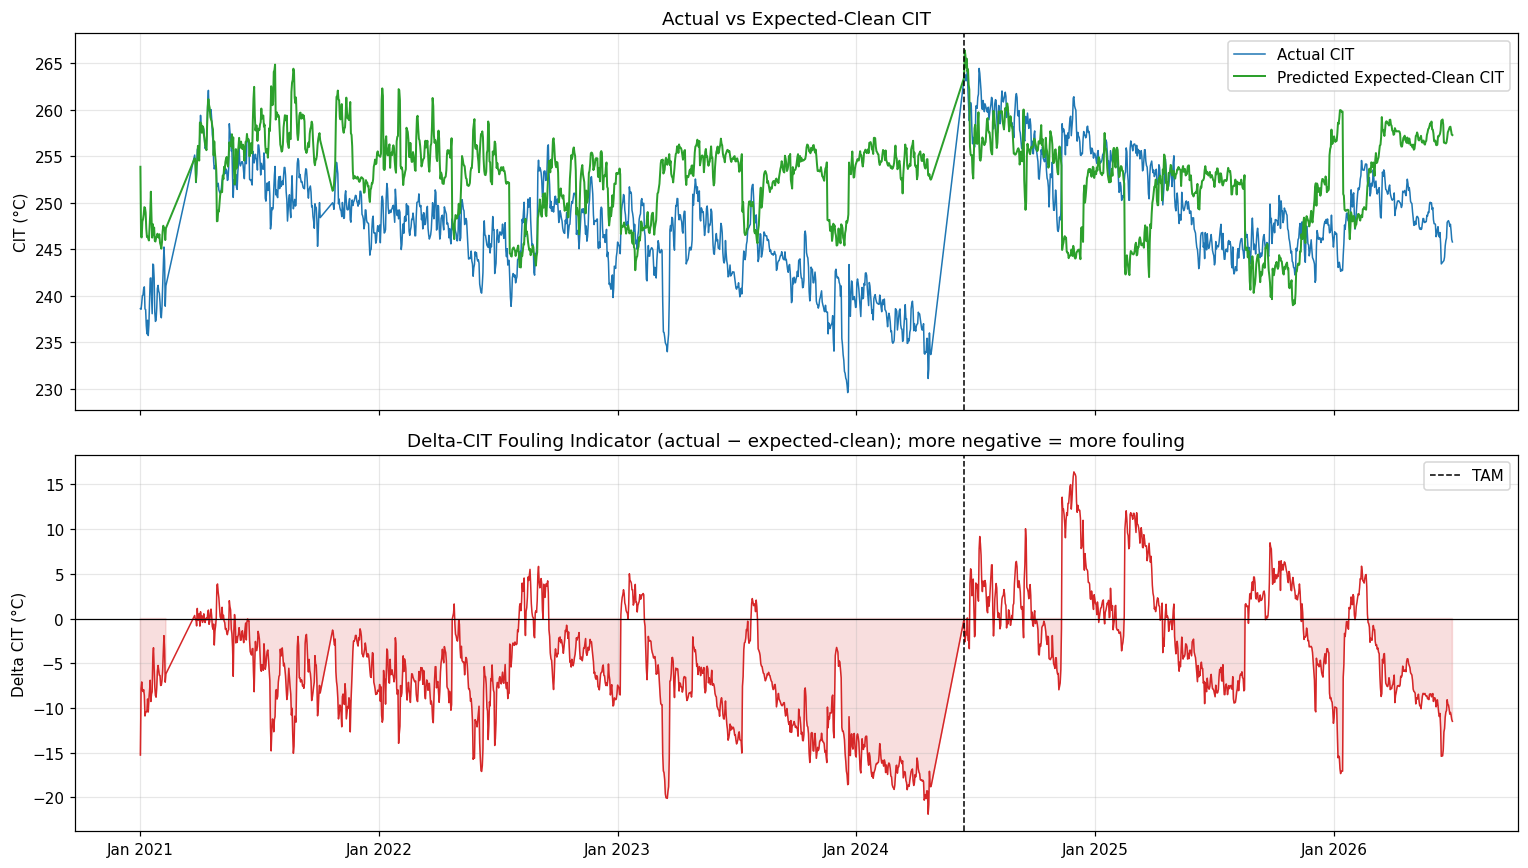

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_all.index, y_all, lw=1, color='tab:blue', label='Actual CIT')
axes[0].plot(predicted_clean_cit.index, predicted_clean_cit, lw=1.3, color='tab:green',
             label='Predicted Expected-Clean CIT')
axes[0].axvline(TAM_DATE, color='black', ls='--', lw=1)
axes[0].set_ylabel('CIT (°C)')
axes[0].set_title('Actual vs Expected-Clean CIT')
axes[0].legend()

axes[1].plot(delta_cit.index, delta_cit, lw=1, color='tab:red')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(TAM_DATE, color='black', ls='--', lw=1, label='TAM')
axes[1].fill_between(delta_cit.index, delta_cit, 0, where=(delta_cit < 0), color='tab:red', alpha=0.15)
axes[1].set_ylabel('Delta CIT (°C)')
axes[1].set_title('Delta-CIT Fouling Indicator (actual − expected-clean); more negative = more fouling')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'delta_cit_fouling_indicator.png', dpi=110, bbox_inches='tight')
plt.show()

In [9]:
delta_cit_df = pd.DataFrame({
    'actual_CIT'          : y_all,
    'predicted_clean_CIT' : predicted_clean_cit,
    'delta_CIT'           : delta_cit,
    'in_clean_baseline'   : clean_mask,
})
# delta_cit_df is kept in-memory for the plot/sandbox below but not exported --
# no downstream script/notebook reads Delta_CIT_Signal.csv (confirmed by repo-wide
# grep, 2026-07-12 pipeline audit); only clean_baseline_sandbox.json (below) feeds 6c.
joblib.dump({'model': champion, 'features': champion_features, 'candidate_name': champion_name},
            MODELS_DIR / 'clean_baseline_cit_model.joblib')
print(f'Saved champion model -> {MODELS_DIR / "clean_baseline_cit_model.joblib"}')

Saved champion model -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\models\clean_baseline_cit_model.joblib


---
## 6. Optimization Sandbox -- Per-HX "Reset to Clean" Counterfactual

For each HX in the champion's feature set, reset its physical features
(`Q_norm`/`dT_cold`/`dT_hot`) to their **clean-baseline median** (the typical
value observed during the post-TAM window for that HX) while holding every
other feature at today's actual value, then re-predict. Because `CIT_lag1`
is no longer a feature, the model has nothing else to lean on -- the
predicted CIT shift comes entirely from the physical duty change, exactly
the "physics responds to a simulated clean" behavior the sandbox needs.

In [10]:
if champion_name != 'top5_hx':
    print('Skipping — champion has no per-HX duty features to reset.')
else:
    clean_reference = X_window[champion_features].median()

    # Reuse the same clipped matrix as the main Delta-CIT computation so the
    # sandbox baseline matches `predicted_clean_cit` exactly (both must stay
    # inside the model's calibrated domain -- see the clipping note above).
    baseline_pred_all = predicted_clean_cit

    sandbox_rows = []
    for hx in TOP5_HX:
        cols = hx_cols(hx)
        X_cf = X_all_clipped.copy()
        for c in cols:
            X_cf[c] = clean_reference[c]
        cf_pred = pd.Series(champion.predict(X_cf), index=X_all.index)
        gain = cf_pred - baseline_pred_all

        deployment_gain = gain[~clean_mask]  # exclude the calibration window itself
        sandbox_rows.append({
            'HX'                : hx,
            'mean_CIT_gain_C'   : deployment_gain.mean(),
            'median_CIT_gain_C' : deployment_gain.median(),
            'CIT_gain_last_day_C': gain.iloc[-1],
            'pct_days_gain_gt_0': (deployment_gain > 0).mean() * 100,
        })

    sandbox_df = pd.DataFrame(sandbox_rows).sort_values('mean_CIT_gain_C', ascending=False).reset_index(drop=True)
    print('Clean-baseline Optimization Sandbox — predicted CIT gain from resetting each HX to its post-TAM clean state:')
    print(sandbox_df.round(3))

Clean-baseline Optimization Sandbox — predicted CIT gain from resetting each HX to its post-TAM clean state:
       HX  mean_CIT_gain_C  median_CIT_gain_C  CIT_gain_last_day_C  \
0  E101EF            4.377              5.587                1.509   
1  E101AB            0.639              0.743                0.268   
2   E113A            0.473             -1.566               -1.566   
3  E105AB            0.355              0.715                0.722   
4  E109AB           -0.101             -0.181                0.377   

   pct_days_gain_gt_0  
0              96.146  
1              98.715  
2              31.692  
3              62.741  
4              45.503  


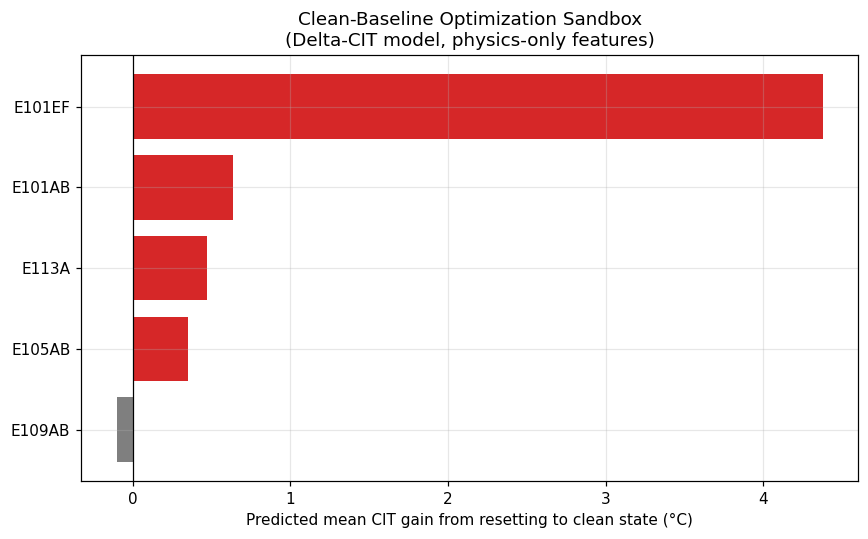

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\dashboard\data\clean_baseline_sandbox.json


In [11]:
if champion_name == 'top5_hx':
    fig, ax = plt.subplots(figsize=(8, 5))
    order = sandbox_df.set_index('HX')['mean_CIT_gain_C'].sort_values()
    colors = ['tab:red' if v > 0 else 'tab:gray' for v in order]
    ax.barh(order.index, order.values, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Predicted mean CIT gain from resetting to clean state (°C)')
    ax.set_title('Clean-Baseline Optimization Sandbox\n(Delta-CIT model, physics-only features)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'clean_baseline_sandbox_gain.png', dpi=110, bbox_inches='tight')
    plt.show()

    # sandbox_df is exported below as clean_baseline_sandbox.json (read by 6c) --
    # Delta_CIT_Cleaning_Gain.csv itself is not exported: no downstream script/notebook
    # reads it (confirmed by repo-wide grep, 2026-07-12 pipeline audit).
    import json as jsonlib
    DASH_DIR.mkdir(parents=True, exist_ok=True)
    sandbox_export = {
        'as_of_date'       : str(X_all.index.max().date()),
        'tam_date'         : str(TAM_DATE.date()),
        'champion_features': champion_features,
        'resettable_hx'    : sandbox_df.round(4).to_dict(orient='records'),
    }
    with open(DASH_DIR / 'clean_baseline_sandbox.json', 'w') as f:
        jsonlib.dump(sandbox_export, f, indent=2)
    print(f'Saved -> {DASH_DIR / "clean_baseline_sandbox.json"}')

---
## 7. Limitations

- **Single calibration event**: only one plant-wide TAM (2024-06-14) exists
  in the dataset, giving ~30 clean-baseline rows total (21 train / 9 test).
  This is far below what either reference method used (`3a` pooled 1,600+
  rows across 15 HX's *independent* clean events; the Sensors 2025 paper and
  the 2020 thesis both had many more cycles or simulated data). Treat
  `Delta_CIT` as a directional indicator, not a calibrated engineering
  quantity, until a second TAM's data is available to cross-validate against.
- **No seasonality term**: the single calibration window is one June, so the
  model cannot separate "it's winter and crude is naturally cooler" from
  "the train is fouled" -- both would show up as negative `Delta_CIT`. Crude
  assay features partially cover crude-slate effects but not ambient/seasonal
  ones.
- **Sandbox only covers 5 HX** (`E109AB`, `E101AB`, `E105AB`, `E101EF`,
  `E113A`) -- the ones in the champion's feature set. A HX not listed here
  can't be "reset" in this sandbox; extending coverage would mean accepting
  even fewer clean-baseline rows per added feature, a real precision/coverage
  trade-off at this sample size.
- **Correlational, not causal** -- same caveat as `6a`'s counterfactual
  simulation. `Delta_CIT` and the sandbox gains are a second, physically-
  motivated opinion to sit alongside `2d`'s engineering ranking and `6a`'s
  autoregressive-model sandbox, not a replacement for either.

---

# Part 2 · Six-Month Forecast & Dashboard Export

*(merged from the former `12_cit_forecast_export.ipynb`, 2026-07-19 — content unchanged, only the
redundant DE-STEP-HEADER/title boilerplate was folded into this notebook's own header above.)*

Answers the project's core question directly: **which HX should be cleaned, and when** — by
linearly extrapolating each HX's fouling-deviation signal 182 days (~6 months) forward from
`Data/Time_To_Clean_Prediction.csv`, then exporting everything the static HTML dashboard needs
as JSON. No new detection/threshold logic is introduced here.


## 0. Imports & Configuration

In [12]:
import json as jsonlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA_DIR      = Path(r'C:\Desktop\Bangchak Internship 2026\Data')
REPO_ROOT     = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization')
OUT_DIR       = REPO_ROOT / 'outputs'
FIG_DIR       = REPO_ROOT / 'figures' / 'forecast_6mo'
DASHBOARD_DIR = REPO_ROOT / 'dashboard' / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_DAYS = 182   # ~6 months look-ahead

---
## 1. Load Inputs

In [13]:
ttc = pd.read_csv(DATA_DIR / 'Time_To_Clean_Prediction.csv')
priority_v2 = pd.read_csv(OUT_DIR / 'hx_Q_cleaning_priority_v2.csv', index_col=0)
model_metrics = pd.read_csv(OUT_DIR / 'Model_Comparison_Metrics.csv')

# Reference 'as of' date -- last timestamp in the underlying process data, same
# basis Time_To_Clean_Prediction.csv itself was built from.
last_date = pd.read_csv(DATA_DIR / 'Process_information_cleaned.csv',
                         index_col='Timestamp', parse_dates=True).index.max()

print(f'Time_To_Clean_Prediction.csv: {ttc.shape[0]} HX rows')
print(f'hx_Q_cleaning_priority_v2.csv: {priority_v2.shape[0]} HX rows')
print(f'As-of date: {last_date.date()}')
ttc.head()

Time_To_Clean_Prediction.csv: 15 HX rows
hx_Q_cleaning_priority_v2.csv: 14 HX rows
As-of date: 2026-07-01


,HX,effort_tier,current_deviation,threshold,threshold_source,threshold_confidence,rate_kW_per_day,rate_source,days_to_threshold,beyond_horizon,projected_need_by_date,at_risk_before_tam
0,E101EF,ONLINE_FULL,3851.275700,2847.789612,own_history,medium,3.395806,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
1,E103AB,TAM_ONLY,1241.733055,515.847990,own_history,high,1.944340,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
2,E109AB,TAM_ONLY,464.907260,203.562426,own_history,high,2.936285,current_run,0.0,False,2026-07-01 00:00:00.000000000,True
3,E104,ONLINE_FULL,2307.678756,613.275061,own_history,high,4.125197,current_run,0.0,False,2026-07-01 00:00:00.000000000,False
4,E110ABC,ONLINE_FULL,2369.801292,1243.302739,own_history,medium,2.959877,current_run,0.0,False,2026-07-01 00:00:00.000000000,False


---
## 2. 182-Day Linear Extrapolation per HX

`projected_deviation(t) = current_deviation + rate_kW_per_day * t`

Only HX with a **positive** fouling rate (deviation growing) can cross their
threshold going forward; HX with a flat/negative rate are marked
`beyond_horizon` (consistent with the convention already used in
`Time_To_Clean_Prediction.csv` / `07_time_to_clean_prediction.ipynb`).

In [14]:
forecast_rows = []
forecast_series = {}

for _, row in ttc.iterrows():
    hx = row['HX']
    current_dev = row['current_deviation']
    threshold   = row['threshold']
    rate        = row['rate_kW_per_day']

    days = np.arange(0, HORIZON_DAYS + 1)
    dates = [last_date + pd.Timedelta(days=int(d)) for d in days]
    projected = current_dev + rate * days

    if current_dev >= threshold:
        # Already past trigger as of the as-of date -- due now, not a future projection.
        days_to_cross = 0.0
    elif rate > 0:
        days_to_cross = (threshold - current_dev) / rate
    else:
        days_to_cross = np.nan

    if pd.notna(days_to_cross) and 0 <= days_to_cross <= HORIZON_DAYS:
        trigger_date = last_date + pd.Timedelta(days=float(days_to_cross))
        within_horizon = True
    else:
        trigger_date = pd.NaT
        within_horizon = False

    forecast_series[hx] = {
        'dates': [d.strftime('%Y-%m-%d') for d in dates],
        'projected_deviation': [round(float(v), 3) for v in projected],
        'threshold': float(threshold),
        'current_deviation': float(current_dev),
    }

    forecast_rows.append({
        'HX'                  : hx,
        'effort_tier'         : row['effort_tier'],
        'current_deviation'   : round(current_dev, 3),
        'threshold'           : round(threshold, 3),
        'rate_kW_per_day'     : round(rate, 5),
        'days_to_threshold_6mo': round(days_to_cross, 1) if pd.notna(days_to_cross) else np.nan,
        'projected_clean_date': trigger_date.date().isoformat() if within_horizon else None,
        'at_risk_within_6mo'  : bool(within_horizon or row['days_to_threshold'] == 0),
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('days_to_threshold_6mo', na_position='last')
print(f'{int(forecast_df["at_risk_within_6mo"].sum())} of {len(forecast_df)} HX projected to need cleaning within 6 months')
forecast_df

9 of 15 HX projected to need cleaning within 6 months

,HX,effort_tier,current_deviation,threshold,rate_kW_per_day,days_to_threshold_6mo,projected_clean_date,at_risk_within_6mo
0,E101EF,ONLINE_FULL,3851.276,2847.790,3.39581,0.0,2026-07-01,True
1,E103AB,TAM_ONLY,1241.733,515.848,1.94434,0.0,2026-07-01,True
2,E109AB,TAM_ONLY,464.907,203.562,2.93629,0.0,2026-07-01,True
3,E104,ONLINE_FULL,2307.679,613.275,4.12520,0.0,2026-07-01,True
4,E110ABC,ONLINE_FULL,2369.801,1243.303,2.95988,0.0,2026-07-01,True
5,E112AB,ONLINE_FULL,2354.911,940.664,0.07701,0.0,2026-07-01,True
6,E113A,SWAP_CAPABLE,2035.846,1609.216,18.76612,0.0,2026-07-01,True
7,E102,ONLINE_FULL,29.978,87.801,0.87881,65.8,2026-09-04,True
8,E107AB,TAM_ONLY,125.295,288.841,1.19725,136.6,2026-11-14,True
9,E101CD,ONLINE_PARTIAL,76.445,466.569,0.73043,534.1,None,False


In [15]:
# --- 80% prediction interval per HX (folded in from the former
#     notebooks/add_forecast_intervals.py post-processor -- that script patched
#     forecast_6mo.json AFTER this notebook wrote it; doing it here means there
#     is exactly one writer of forecast_6mo.json, with the complete schema from
#     the start, matching the fix already applied to the other overwrite chains
#     documented in docs/CURRENT_PIPELINE_MAP.md) ---
#
# The point forecast above is a single deterministic line (current_dev +
# rate*t). A point forecast with no uncertainty over-states confidence.
# Fouling deviation behaves like a drifting/random-walk series, so forecast
# uncertainty grows with the square-root of the horizon:
#   band(t) = z * sigma_daily * sqrt(1 + t / n_fit), z=1.28 -> ~80% interval
# sigma_daily is the residual std (around the CURRENT run's own linear trend,
# not the raw day-to-day diff -- otherwise the cone explodes) computed from
# Q_Deviation_Signal.csv's per-timestamp Q-duty deviation series.

Z_INTERVAL = 1.28  # ~80% band

q_dev = pd.read_csv(DATA_DIR / 'Q_Deviation_Signal.csv', parse_dates=['Timestamp'])

def _interval_fit_stats(hx):
    """Residual std around the CURRENT run's linear deviation trend + run length."""
    d = q_dev[q_dev['HX'] == hx]
    if d.empty or 'run_id' not in d.columns:
        return None, None
    last_run = d['run_id'].dropna().iloc[-1] if d['run_id'].notna().any() else None
    cur = d[d['run_id'] == last_run] if last_run is not None else d.tail(60)
    cur = cur.sort_values('Timestamp')
    dev = cur['deviation'].astype(float).values
    if len(dev) < 8:
        return None, None
    t = np.arange(len(dev), dtype=float)
    b, a = np.polyfit(t, dev, 1)
    resid = dev - (a + b * t)
    return float(np.std(resid)), len(dev)

n_with_interval = 0
for hx, entry in forecast_series.items():
    sigma, n_fit = _interval_fit_stats(hx)
    proj = entry['projected_deviation']
    if sigma is None or not np.isfinite(sigma) or sigma == 0:
        # no reliable fit -> flat 5% band so the chart still shows a cone
        band = [max(0.02 * abs(v), 0.05) * Z_INTERVAL for v in proj]
    else:
        band = [Z_INTERVAL * sigma * np.sqrt(1 + i / max(n_fit, 1)) for i in range(len(proj))]
        n_with_interval += 1
    entry['projected_upper'] = [round(v + b, 3) for v, b in zip(proj, band)]
    entry['projected_lower'] = [round(max(0.0, v - b), 3) for v, b in zip(proj, band)]
    entry['interval_pct'] = 80
    entry['sigma_daily'] = round(sigma, 4) if sigma else None

print(f'Added 80% prediction intervals to {len(forecast_series)} HX '
      f'({n_with_interval} from a fitted current-run residual, rest flat fallback band)')

Added 80% prediction intervals to 15 HX (15 from a fitted current-run residual, rest flat fallback band)


---
## 3. Final Cleaning-Recommendation Table

Combines the SHAP-based priority ranking (`6b`) with the 6-month forecast
(section 2) — this is the direct answer to "which HX, and when."

In [16]:
recommendation = priority_v2[['priority_score', 'cit_shap_importance', 'Q_fouling_rate_abs',
                               'recommended_action']].copy()
recommendation['priority_rank'] = recommendation['priority_score'].rank(ascending=False).astype(int)

fc_indexed = forecast_df.set_index('HX')
recommendation = recommendation.join(
    fc_indexed[['effort_tier', 'projected_clean_date', 'at_risk_within_6mo', 'days_to_threshold_6mo']]
)
recommendation = recommendation.sort_values('priority_rank')

out_path = OUT_DIR / 'Cleaning_Recommendation_Final.csv'
recommendation.to_csv(out_path)
print(f'Saved -> {out_path}')
recommendation.round(3)

Saved -> C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\Cleaning_Recommendation_Final.csv


,priority_score,cit_shap_importance,Q_fouling_rate_abs,recommended_action,priority_rank,effort_tier,projected_clean_date,at_risk_within_6mo,days_to_threshold_6mo
HX,,,,,,,,,
E113A,1.000,0.561,5.305,Clean now (past trigger),1,SWAP_CAPABLE,2026-07-01,True,0.0
E112AB,0.929,0.344,1.079,Stable / monitor,2,ONLINE_FULL,2026-07-01,True,0.0
E110ABC,0.857,0.140,0.000,Clean now (past trigger),3,ONLINE_FULL,2026-07-01,True,0.0
E101AB,0.786,0.256,0.532,Clean now (past trigger),4,ONLINE_FULL,None,False,NaN
E104,0.714,0.401,0.361,Clean now (past trigger),5,ONLINE_FULL,2026-07-01,True,0.0
E108AB,0.643,0.083,0.000,Clean now (past trigger),6,ONLINE_FULL,None,False,NaN
E103AB,0.571,0.087,1.105,Clean now (past trigger),7,TAM_ONLY,2026-07-01,True,0.0
E101CD,0.500,0.090,0.467,Stable / monitor,8,ONLINE_PARTIAL,None,False,534.1
E102,0.429,0.150,0.221,Clean now (past trigger),9,ONLINE_FULL,2026-09-04,True,65.8


In [17]:
print('='*70)
print('FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)')
print('='*70)
for hx, row in recommendation.head(8).iterrows():
    when = row['projected_clean_date'] if pd.notna(row['projected_clean_date']) else row['recommended_action']
    print(f"  #{int(row['priority_rank'])}  {hx:<10}  priority={row['priority_score']:.3f}  "
          f"effort={row['effort_tier']:<26}  clean by: {when}")
print('='*70)

FINAL CLEANING RECOMMENDATIONS (priority rank + 6-month forecast)
  #1  E113A       priority=1.000  effort=SWAP_CAPABLE                clean by: 2026-07-01
  #2  E112AB      priority=0.929  effort=ONLINE_FULL                 clean by: 2026-07-01
  #3  E110ABC     priority=0.857  effort=ONLINE_FULL                 clean by: 2026-07-01
  #4  E101AB      priority=0.786  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #5  E104        priority=0.714  effort=ONLINE_FULL                 clean by: 2026-07-01
  #6  E108AB      priority=0.643  effort=ONLINE_FULL                 clean by: Clean now (past trigger)
  #7  E103AB      priority=0.571  effort=TAM_ONLY                    clean by: 2026-07-01
  #8  E101CD      priority=0.500  effort=ONLINE_PARTIAL              clean by: Stable / monitor


---
## 4. Plot: 6-Month Forecast for Top-Priority HX

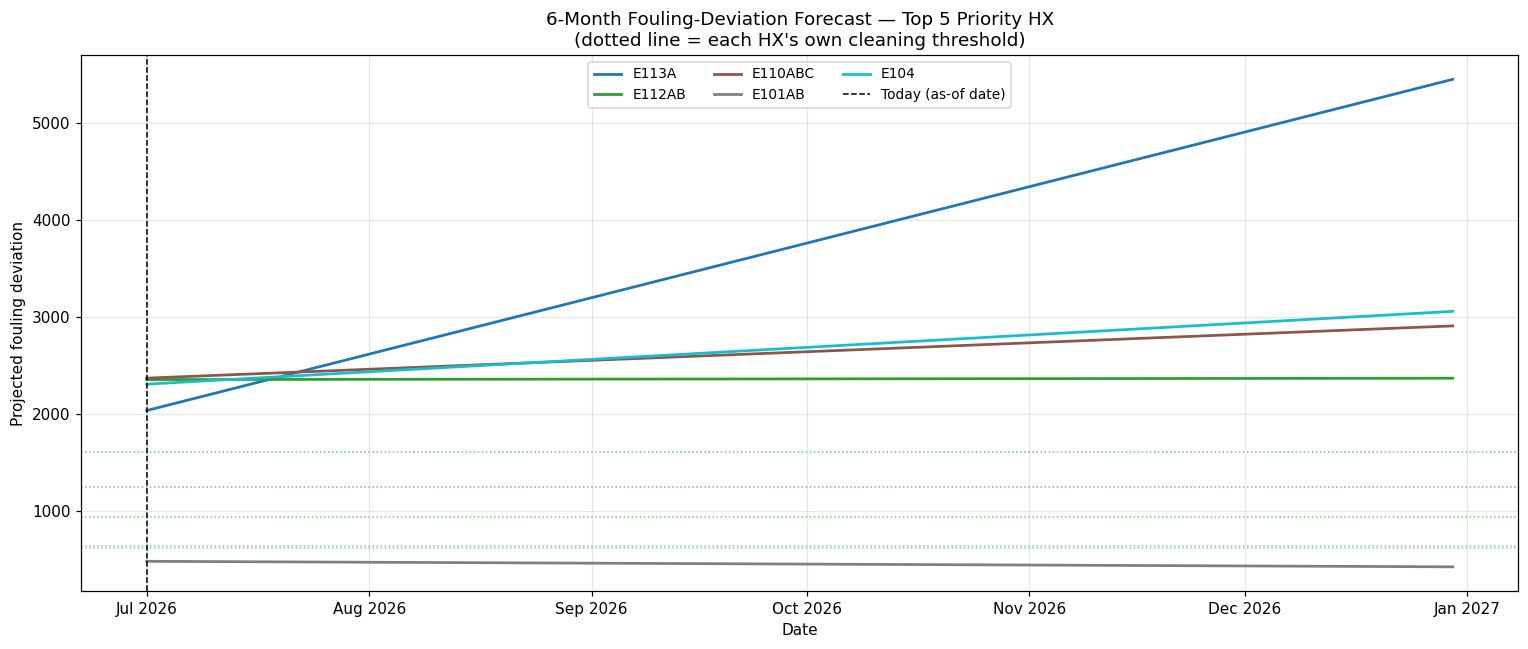

In [18]:
top5 = recommendation.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))
for hx, color in zip(top5, colors):
    fc = forecast_series[hx]
    dates = pd.to_datetime(fc['dates'])
    ax.plot(dates, fc['projected_deviation'], lw=1.8, color=color, label=f'{hx}')
    ax.axhline(fc['threshold'], color=color, ls=':', lw=1, alpha=0.6)

ax.axvline(last_date, color='black', ls='--', lw=1, label='Today (as-of date)')
ax.set_ylabel('Projected fouling deviation')
ax.set_xlabel('Date')
ax.set_title('6-Month Fouling-Deviation Forecast — Top 5 Priority HX\n(dotted line = each HX\'s own cleaning threshold)')
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'six_month_forecast_top5.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 5. Export Dashboard Data (`dashboard/data/*.json`)

In [19]:
# hx_ranking.json -- SHAP-based cleaning priority table
hx_ranking = priority_v2.reset_index().rename(columns={'index': 'HX'})
hx_ranking.columns = ['HX'] + list(hx_ranking.columns[1:])
hx_ranking_records = jsonlib.loads(hx_ranking.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'hx_ranking.json', 'w') as f:
    jsonlib.dump(hx_ranking_records, f, indent=2)

# forecast_6mo.json -- per-HX daily projected series, incl. the 80% prediction
# interval computed above (projected_upper/lower/interval_pct/sigma_daily)
with open(DASHBOARD_DIR / 'forecast_6mo.json', 'w') as f:
    jsonlib.dump(forecast_series, f, indent=2)

# NOTE: model_metrics.json is intentionally NOT written here. This notebook's
# Model_Comparison_Metrics.csv (single 80/20 split) looks better than the model
# actually performs out-of-sample -- see docs/project_cit_persistence_finding.
# pipeline/gen_honest_metrics.py is the sole writer of model_metrics.json,
# using walk-forward CV + a persistence baseline instead. It runs as its own
# post-processing step in pipeline/run_all.py (step 1 of the POST list) after
# this notebook.

# cleaning_recommendations.json -- final synthesized table
reco_export = recommendation.reset_index().rename(columns={'index': 'HX'})
reco_records = jsonlib.loads(reco_export.round(4).to_json(orient='records'))
with open(DASHBOARD_DIR / 'cleaning_recommendations.json', 'w') as f:
    jsonlib.dump(reco_records, f, indent=2)

print('Exported dashboard data files:')
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    print(' -', f.name, f'({f.stat().st_size:,} bytes)')

Exported dashboard data files:
 - cit_floor_override.json (27 bytes)
 - clean_baseline_sandbox.json (1,546 bytes)
 - cleaning_history.json (50,043 bytes)
 - cleaning_logistics.json (10,280 bytes)
 - cleaning_plan.json (36,914 bytes)
 - cleaning_recommendations.json (4,946 bytes)
 - cleaning_schedule.json (11,422 bytes)
 - cleaning_schedule_v2.json (22,128 bytes)
 - cost_overrides.json (2 bytes)
 - drivers.json (1,426 bytes)
 - economics.json (13,806 bytes)
 - end_of_run.json (24,257 bytes)
 - engineering_priority.json (17,082 bytes)
 - evidence.json (8,009 bytes)
 - forecast_6mo.json (192,068 bytes)
 - hx_ranking.json (6,717 bytes)
 - hx_timeseries.json (972,872 bytes)
 - model_metrics.json (3,527 bytes)
 - opt_params.json (25 bytes)
 - pfd_topology.json (21,245 bytes)
 - propagation_models.json (40,129 bytes)
 - reliability.json (61,901 bytes)
 - rul.json (3,424 bytes)
 - tam_analysis.json (19,819 bytes)
 - tam_comparison.json (1,707 bytes)


In [20]:
# Validate every exported file is well-formed JSON
for f in sorted(DASHBOARD_DIR.glob('*.json')):
    with open(f) as fh:
        obj = jsonlib.load(fh)
    n = len(obj) if isinstance(obj, list) else len(obj.keys())
    print(f'{f.name}: OK ({n} top-level entries)')

cit_floor_override.json: OK (1 top-level entries)
clean_baseline_sandbox.json: OK (4 top-level entries)
cleaning_history.json: OK (3 top-level entries)
cleaning_logistics.json: OK (5 top-level entries)
cleaning_plan.json: OK (30 top-level entries)
cleaning_recommendations.json: OK (14 top-level entries)
cleaning_schedule.json: OK (10 top-level entries)
cleaning_schedule_v2.json: OK (34 top-level entries)
cost_overrides.json: OK (0 top-level entries)
drivers.json: OK (7 top-level entries)
economics.json: OK (13 top-level entries)
end_of_run.json: OK (4 top-level entries)
engineering_priority.json: OK (14 top-level entries)
evidence.json: OK (8 top-level entries)
forecast_6mo.json: OK (15 top-level entries)
hx_ranking.json: OK (14 top-level entries)
hx_timeseries.json: OK (16 top-level entries)
model_metrics.json: OK (9 top-level entries)
opt_params.json: OK (1 top-level entries)
pfd_topology.json: OK (11 top-level entries)
propagation_models.json: OK (5 top-level entries)
reliability.js

---
## Summary

- **6-month forecast**: linear extrapolation of each HX's validated fouling
  deviation rate against its own cleaning threshold, 182 days forward from the
  latest process data, with an 80% prediction interval (section 2b) computed
  from each HX's current-run residual spread.
- **Final recommendation**: `outputs/Cleaning_Recommendation_Final.csv` merges
  SHAP-based priority rank (`6b`) with the projected cleaning date (this notebook)
  — this is the direct "which HX, and when" answer.
- **Dashboard data**: `dashboard/data/hx_ranking.json`, `forecast_6mo.json`,
  `cleaning_recommendations.json` — consumed by `dashboard/index.html`.
  `model_metrics.json` is written separately by `pipeline/gen_honest_metrics.py`,
  not this notebook (see section 5's note).